In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [3]:
wine = load_wine(as_frame=True)

#Quick reminder on information contained in the data
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
wine.frame.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
X, y = wine.data, wine.target

In [6]:
#target is three classes with similar representation
wine.frame['target'].value_counts(normalize = True)

target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64

In [7]:
# Preparing the data
# one hot encoded version of the *target*

y_ohe = to_categorical(y)
y_ohe[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

a `Sequential` model named `model` with one hidden layer containing 100 nodes using the `relu` activation function.  For the output layer, be sure to use the `softmax` activation with 3 nodes (because of the three classes) instead of the `sigmoid` used for binary classification.  

In [8]:

tf.random.set_seed(42)
model = Sequential([Dense(100, activation = 'relu'),
                   Dense(3, activation = 'softmax')])

model

<Sequential name=sequential, built=False>

In [9]:
# Compiling the model
tf.random.set_seed(42)
model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'])

model.loss

'categorical_crossentropy'

In [10]:
# Fitting the model
tf.random.set_seed(42)
history = model.fit(X, y_ohe, validation_split=0.2, epochs = 100, verbose = 2)
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

Epoch 1/100
5/5 - 1s - 126ms/step - accuracy: 0.4718 - loss: 26.5914 - val_accuracy: 0.0000e+00 - val_loss: 18.3772
Epoch 2/100
5/5 - 0s - 12ms/step - accuracy: 0.7676 - loss: 2.0010 - val_accuracy: 0.2778 - val_loss: 1.9355
Epoch 3/100
5/5 - 0s - 12ms/step - accuracy: 0.7676 - loss: 1.1855 - val_accuracy: 0.0000e+00 - val_loss: 15.2660
Epoch 4/100
5/5 - 0s - 12ms/step - accuracy: 0.8099 - loss: 1.2919 - val_accuracy: 0.0000e+00 - val_loss: 10.2169
Epoch 5/100
5/5 - 0s - 13ms/step - accuracy: 0.7676 - loss: 1.2368 - val_accuracy: 0.0000e+00 - val_loss: 12.4251
Epoch 6/100
5/5 - 0s - 13ms/step - accuracy: 0.7746 - loss: 1.6964 - val_accuracy: 0.0000e+00 - val_loss: 3.2289
Epoch 7/100
5/5 - 0s - 12ms/step - accuracy: 0.7113 - loss: 1.9532 - val_accuracy: 0.0000e+00 - val_loss: 13.7638
Epoch 8/100
5/5 - 0s - 13ms/step - accuracy: 0.7817 - loss: 1.2776 - val_accuracy: 0.0000e+00 - val_loss: 8.4953
Epoch 9/100
5/5 - 0s - 12ms/step - accuracy: 0.7535 - loss: 1.5394 - val_accuracy: 0.6667 - v

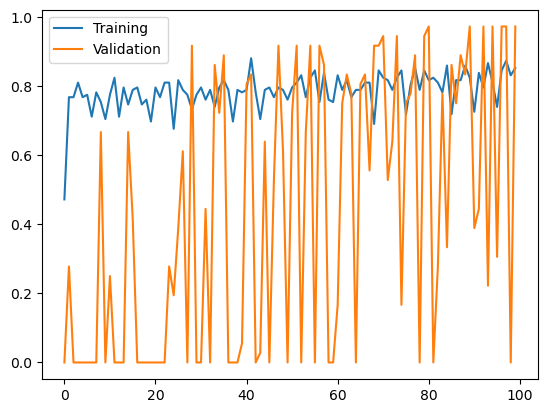

In [11]:
# Is the model overfit?

accuracies = history.history['accuracy']
validation_accuracies = history.history['val_accuracy']

plt.plot(accuracies, label = 'Training')
plt.plot(validation_accuracies, label = 'Validation')
plt.legend();

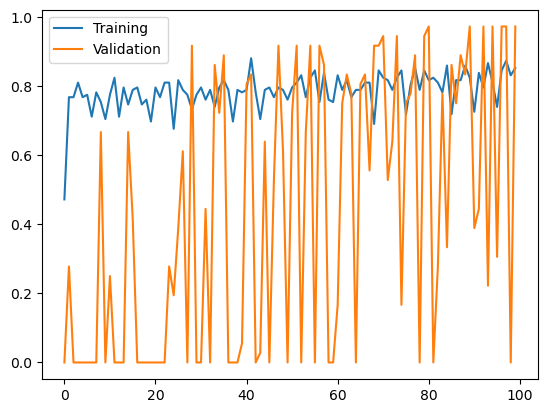

In [12]:
# Fit to a scaled version of the `X

tf.random.set_seed(42)
X_scaled = StandardScaler().fit_transform(X)
model = Sequential([Dense(100, activation = 'relu'),
                   Dense(3, activation = 'softmax')])
model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_scaled, y_ohe, epochs = 100, verbose = 0, validation_split=0.2)


## Uncomment to visualize
plt.plot(accuracies, label = 'Training')
plt.plot(validation_accuracies, label = 'Validation')
plt.legend();